# Sobol — indices and Figure 5

Compute the first-order ($S_1$) and total-order ($S_T$) Sobol indices for each
of the 5 parameters, 3 metrics, and 6 stations, and plot Figure 5 of the
manuscript.

In `mode: test` the results have very wide confidence intervals — this notebook
still produces the figure but with high uncertainty bars. Production mode is
required to reproduce the published Figure 5.

Inputs: `data/sobol_results.parquet`, `data/forcings_global.zarr` (for the
station temperature mean used to sort the x-axis).
Output: `figures/Figure_5.{pdf,png}`.


In [1]:
import json
import string
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import yaml
from SALib import ProblemSpec


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    SOBOL = yaml.safe_load(f)["sobol"]
with open(DATA_DIR / "stations_coords.json") as f:
    STATIONS = json.load(f)

PARAMS = SOBOL["parameters_ordered"]
BOUNDS = [SOBOL["bounds"][p] for p in PARAMS]
METRICS = SOBOL["metrics"]

sns.set_context("paper", font_scale=1.2)
sns.set_style("white", {"axes.edgecolor": "black", "axes.linewidth": 0.8})

## Compute Sobol indices

SALib needs the result count to be a multiple of `(2P+2)`. The notebook
automatically truncates the parquet to the largest valid count, which lets
the figure render even when the simulation file is incomplete (resumable run).


In [2]:
results = pd.read_parquet(DATA_DIR / "sobol_results.parquet")
# IMPORTANT: results.columns.levels[i] is alphabetically sorted; use unique()
# on the actual level values to preserve the column insertion order (otherwise
# stations and metrics get scrambled relative to the data).
stations = list(results.columns.get_level_values(0).unique())
metrics = list(results.columns.get_level_values(1).unique())
outputs = [f"{s}_{m}" for s in stations for m in metrics]

P = len(PARAMS)
MULT = 2 * P + 2
n_full = (len(results) // MULT) * MULT
print(f"Using {n_full:,} / {len(results):,} rows (truncated to multiple of {MULT}).")
print(f"Stations order (insertion): {stations}")
print(f"Metrics order (insertion):  {metrics}")

sp = ProblemSpec({
    "names": PARAMS,
    "groups": None,
    "bounds": BOUNDS,
    "outputs": outputs,
})
sp.set_results(results.to_numpy()[:n_full])
sp.analyze_sobol()

Using 12,288 / 12,288 rows (truncated to multiple of 12).
Stations order (insertion): ['HOT', 'Canaries', 'BATS', 'Bay_of_Biscay', 'PAPA', 'BARENTS']
Metrics order (insertion):  ['mean', 'variance', 'argmax']


Outputs:
	18 outputs: ['HOT_mean', 'HOT_variance', 'HOT_argmax', 'Canaries_mean', 'Canaries_variance', 'Canaries_argmax', 'BATS_mean', 'BATS_variance', 'BATS_argmax', 'Bay_of_Biscay_mean', 'Bay_of_Biscay_variance', 'Bay_of_Biscay_argmax', 'PAPA_mean', 'PAPA_variance', 'PAPA_argmax', 'BARENTS_mean', 'BARENTS_variance', 'BARENTS_argmax']
	12288 evaluations
Analysis:
HOT_mean:
                                ST   ST_conf
energy_transfert          0.293683  0.074849
tr_0                      0.000323  0.000357
gamma_tr                  0.000986  0.000657
lambda_temperature_0      0.758982  0.162221
gamma_lambda_temperature  0.306627  0.078714:
                                S1   S1_conf
energy_transfert          0.104462  0.039434
tr_0                      0.000551  0.000808
gamma_tr                  0.000484  0.001222
lambda_temperature_0      0.385085  0.130813
gamma_lambda_temperature  0.109488  0.034326:
                                                        S2   S2_conf
(energy_tran

In [3]:
rows = []
for st in stations:
    for met in metrics:
        key = f"{st}_{met}"
        for i, p in enumerate(PARAMS):
            rows.append({
                "station": st, "metric": met, "parameter": p,
                "S1": sp.analysis[key]["S1"][i],   "S1_conf": sp.analysis[key]["S1_conf"][i],
                "ST": sp.analysis[key]["ST"][i],   "ST_conf": sp.analysis[key]["ST_conf"][i],
            })
indices = pd.DataFrame(rows)
indices.head()

,station,metric,parameter,S1,S1_conf,ST,ST_conf
0,HOT,mean,energy_transfert,0.104462,0.039434,0.293683,0.074849
1,HOT,mean,tr_0,0.000551,0.000808,0.000323,0.000357
2,HOT,mean,gamma_tr,0.000484,0.001222,0.000986,0.000657
3,HOT,mean,lambda_temperature_0,0.385085,0.130813,0.758982,0.162221
4,HOT,mean,gamma_lambda_temperature,0.109488,0.034326,0.306627,0.078714


## Order stations by mean temperature (coldest to warmest)

The x-axis of Figure 5 sorts the 6 stations along the temperature gradient.
The mean temperature at each station is computed from `forcings_global.zarr`
if available, otherwise from `stations.zarr`.


In [4]:
def _station_mean_temp(sid: str) -> float:
    fg_path = DATA_DIR / "forcings_global.zarr"
    info = STATIONS[sid]
    if fg_path.exists():
        ds = xr.open_zarr(fg_path)
        y = int(np.abs(ds["Y"] - info["lat"]).argmin().values)
        x = int(np.abs(ds["X"] - info["lon"]).argmin().values)
        return float(ds.temperature.isel(Y=y, X=x).mean().values)
    st = xr.open_zarr(DATA_DIR / "stations.zarr")
    return float(st.temperature.sel(station=sid).mean().values)


station_temp = {s: _station_mean_temp(s) for s in stations}
station_order = sorted(stations, key=lambda s: station_temp[s])
for s in station_order:
    print(f"  {s}: {station_temp[s]:.1f} degC")

/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reprod

  BARENTS: 0.7 degC
  PAPA: 9.2 degC
  Bay_of_Biscay: 13.9 degC
  Canaries: 19.3 degC
  BATS: 21.5 degC
  HOT: 23.9 degC


/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/ash/Documents/Workspace/SeapoPym-Article-1/seapopym-v0.1-reproducibility/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


## Figure 5 — $S_1$ vs $S_T$ across stations, metrics, and parameters


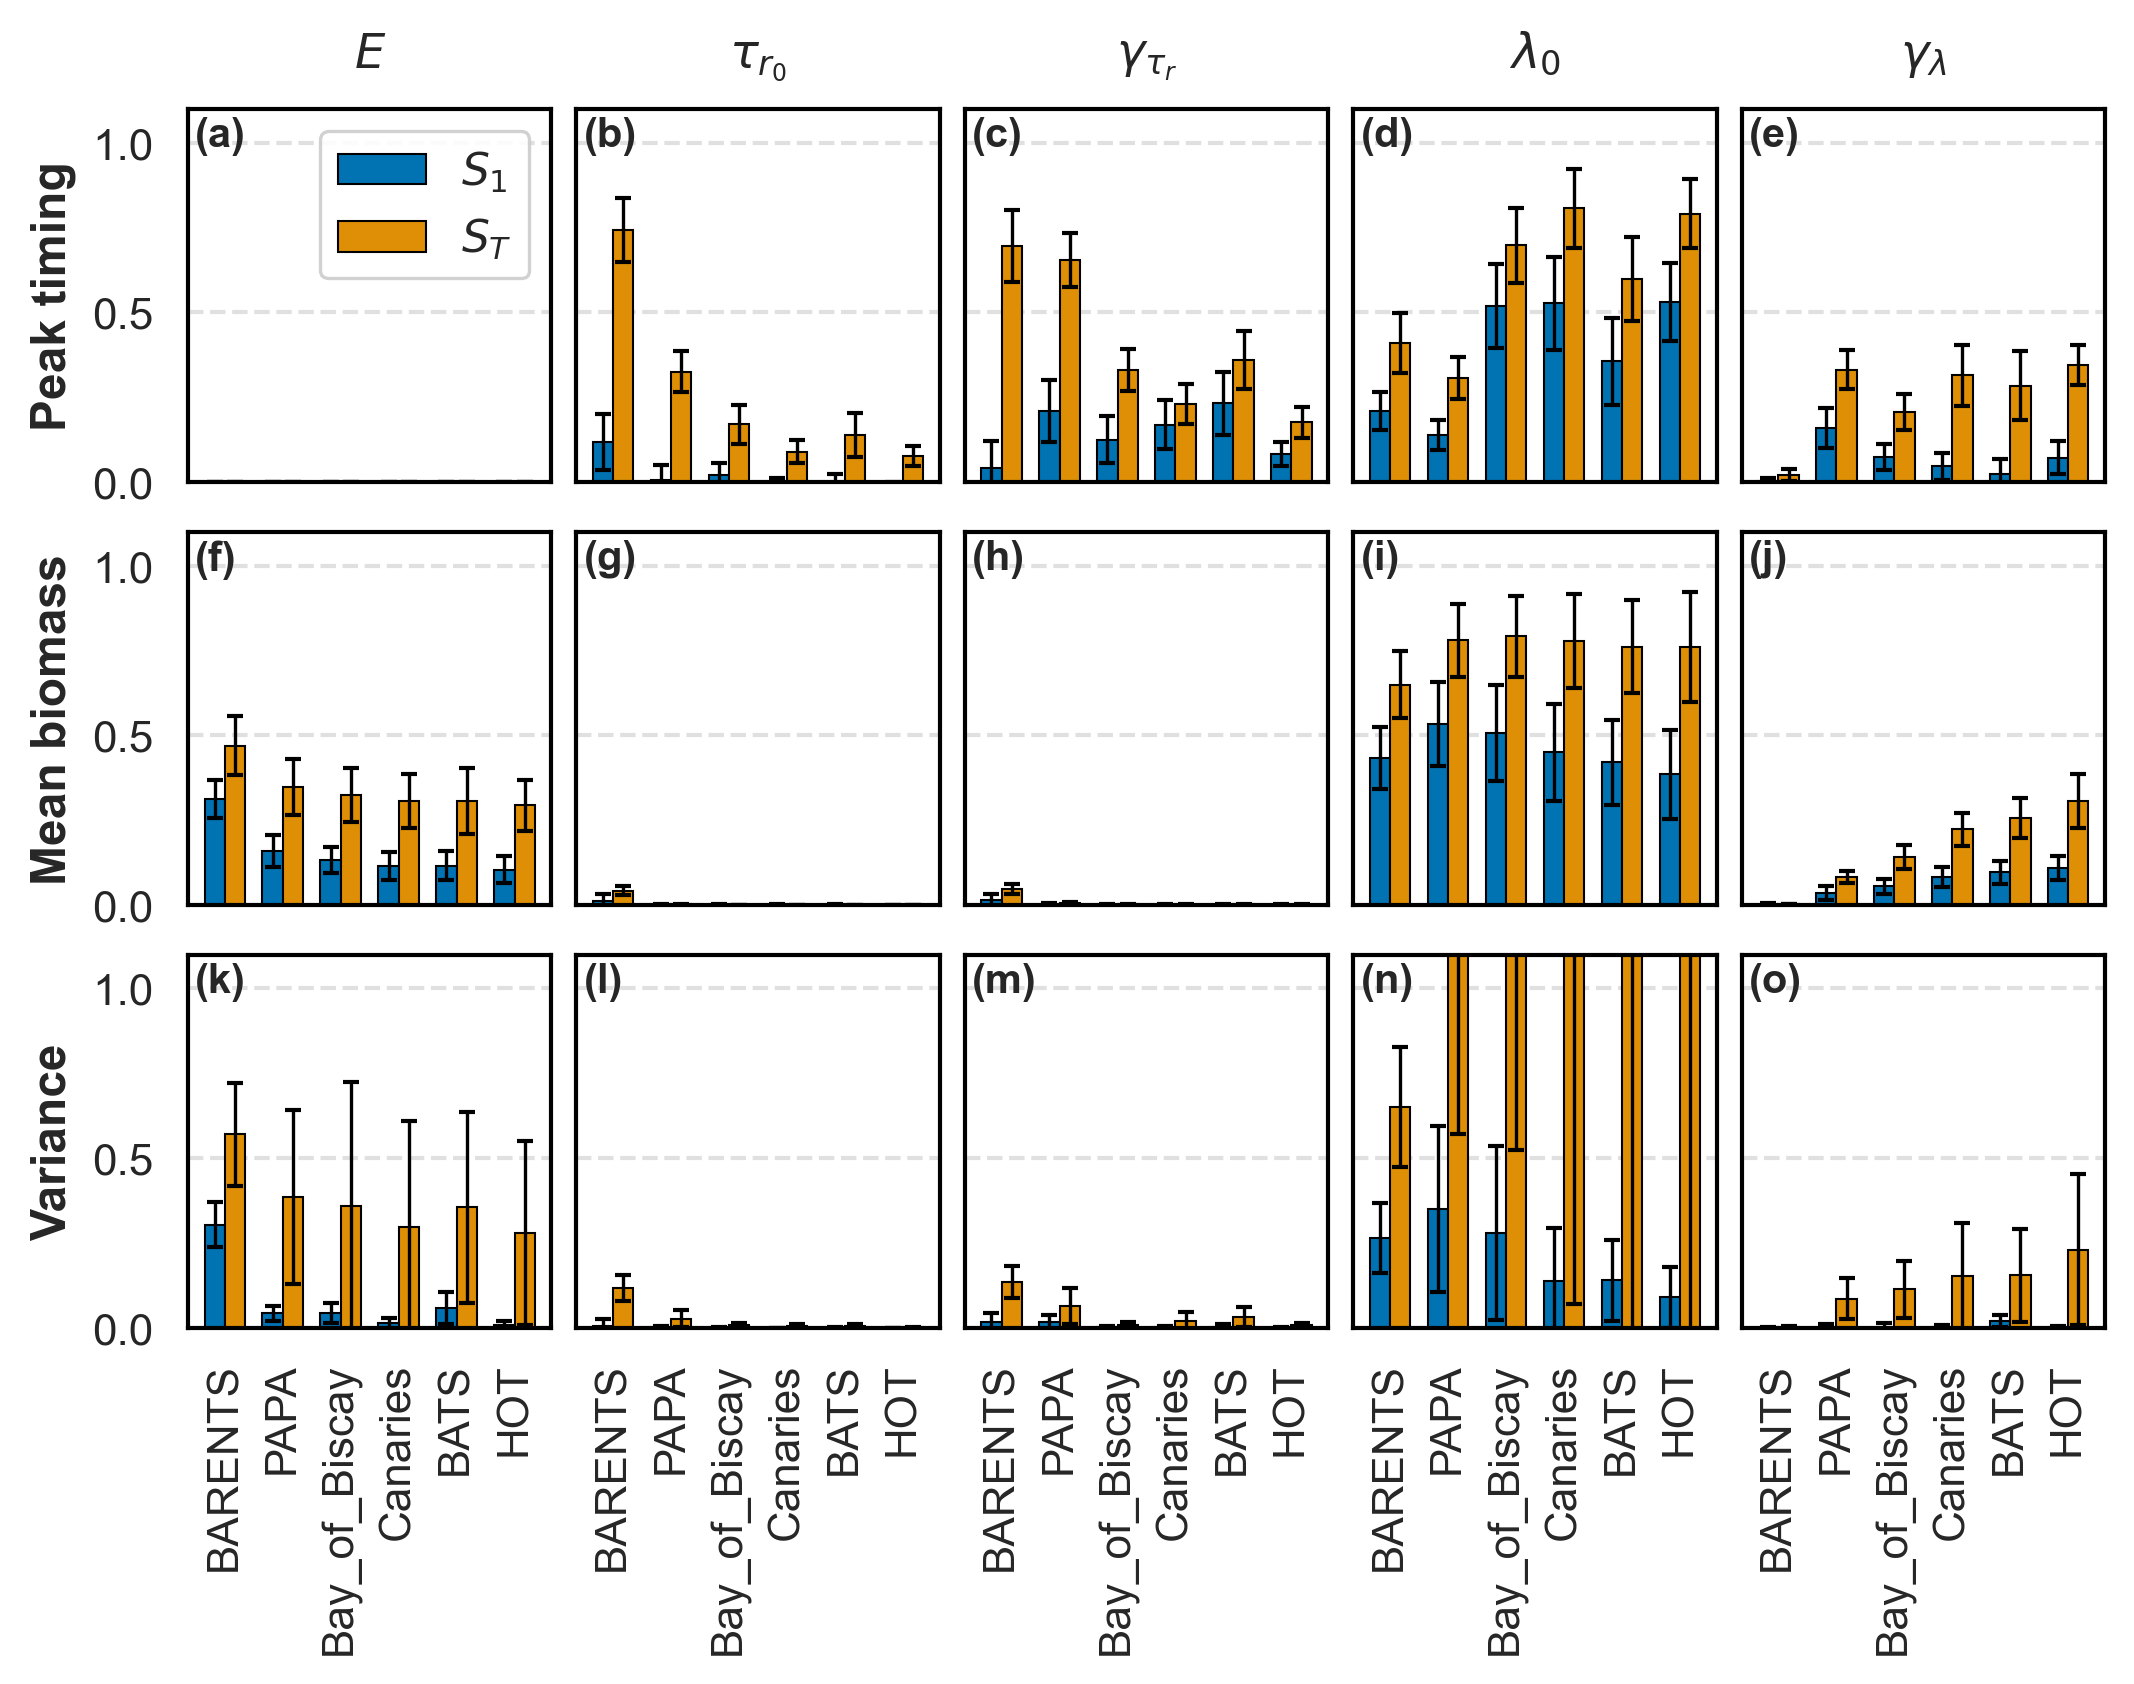

In [5]:
PARAM_LABELS = {
    "energy_transfert": r"$E$",
    "tr_0": r"$\tau_{r_0}$",
    "gamma_tr": r"$\gamma_{\tau_r}$",
    "lambda_temperature_0": r"$\lambda_0$",
    "gamma_lambda_temperature": r"$\gamma_\lambda$",
}
METRIC_LABELS = {"argmax": "Peak timing", "mean": "Mean biomass", "variance": "Variance"}
QOIS = ["argmax", "mean", "variance"]
Y_MAX = 1.1
BAR_WIDTH = 0.35
COLOR_S1 = "#0173B2"
COLOR_ST = "#DE8F05"

fig, axes = plt.subplots(len(QOIS), len(PARAMS), figsize=(7.0, 5.5),
                         constrained_layout=True, sharey=True, dpi=300)
panel = 0

for i, met in enumerate(QOIS):
    for j, par in enumerate(PARAMS):
        ax = axes[i, j]
        sub = indices[(indices["metric"] == met) & (indices["parameter"] == par)].copy()
        sub["station"] = pd.Categorical(sub["station"], categories=station_order, ordered=True)
        sub = sub.sort_values("station")

        x = np.arange(len(station_order))
        ax.bar(x - BAR_WIDTH/2, sub["S1"], BAR_WIDTH, color=COLOR_S1, edgecolor="black", linewidth=0.5, label="$S_1$")
        ax.bar(x + BAR_WIDTH/2, sub["ST"], BAR_WIDTH, color=COLOR_ST, edgecolor="black", linewidth=0.5, label="$S_T$")
        ax.errorbar(x - BAR_WIDTH/2, sub["S1"], yerr=sub["S1_conf"], fmt="none", ecolor="black", elinewidth=0.8, capsize=2)
        ax.errorbar(x + BAR_WIDTH/2, sub["ST"], yerr=sub["ST_conf"], fmt="none", ecolor="black", elinewidth=0.8, capsize=2)

        ax.set_ylim(0, Y_MAX)
        ax.set_yticks(np.arange(0, Y_MAX + 0.1, 0.5))
        ax.grid(axis="y", linestyle="--", alpha=0.6, linewidth=1.0)
        ax.set_axisbelow(True)
        if i == len(QOIS) - 1:
            ax.set_xticks(x); ax.set_xticklabels(station_order, rotation=90)
        else:
            ax.set_xticks([])
        if i == 0:
            ax.set_title(PARAM_LABELS[par], fontweight="bold", pad=10)
        if j == 0:
            ax.set_ylabel(METRIC_LABELS[met], fontweight="bold")
        ax.text(0.02, 0.98, f"({string.ascii_lowercase[panel]})",
                transform=ax.transAxes, fontsize=10, fontweight="bold", va="top", ha="left")
        panel += 1
        if i == 0 and j == 0:
            ax.legend(loc="upper right", framealpha=0.9)

fig.savefig(FIGURES_DIR / "Figure_5.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_5.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()